# PROBLEM STATEMENT

You own an ice cream business and you would like to create a model that could predict the daily revenue in dollars based on the outside air temperature (degC). You decide that a Linear Regression model might be a good candidate to solve this problem.  
Data set:
- Independant variable X: Outside Air Temperature
- Dependant variable Y: Overall daily revenue generated in dollars

# STEP #1: LIBRARIES IMPORT


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# STEP #2: IMPORT DATASET

In [53]:
IceCream = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/IceCreamData.csv")

In [54]:
IceCream.head(100)

,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194
...,...,...
95,9.018860,212.591740
96,20.265012,474.749392
97,19.363153,460.402500
98,14.685944,343.362905


In [55]:
IceCream.tail()

,Temperature,Revenue
495,22.274899,524.746364
496,32.893092,755.818399
497,12.588157,306.090719
498,22.362402,566.217304
499,28.957736,655.660388


In [56]:
IceCream.describe()

,Temperature,Revenue
count,500.000000,500.000000
mean,22.232225,521.570777
std,8.096388,175.404751
min,0.000000,10.000000
25%,17.122258,405.558681
50%,22.392791,529.368565
75%,27.740674,642.257922
max,45.000000,1000.000000


In [57]:
IceCream.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


# STEP#3: VISUALIZE DATASET

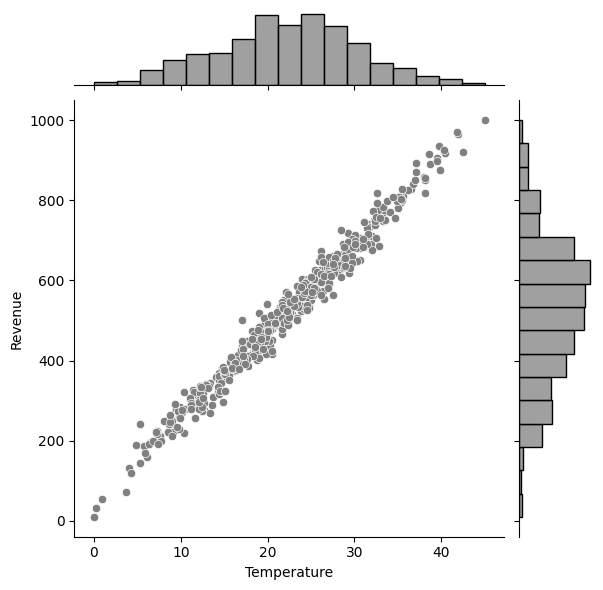

In [58]:
sns.jointplot(x='Temperature', y='Revenue', data = IceCream, color = 'gray')

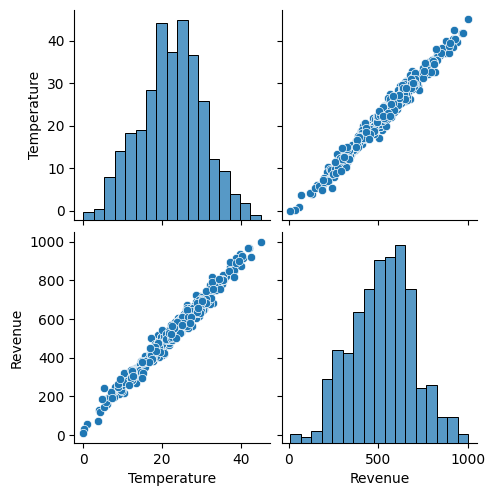

In [59]:
sns.pairplot(IceCream)

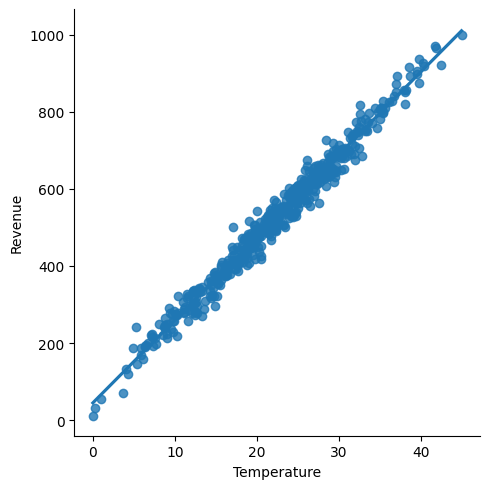

In [60]:
sns.lmplot(x='Temperature', y='Revenue', data=IceCream)

# STEP#4: CREATE TESTING AND TRAINING DATASET

In [61]:
y = IceCream['Revenue']

In [62]:
X = IceCream[['Temperature']]

In [63]:
X

,Temperature
0,24.566884
1,26.005191
2,27.790554
3,20.595335
4,11.503498
...,...
495,22.274899
496,32.893092
497,12.588157
498,22.362402


In [64]:
from sklearn.model_selection import train_test_split

In [65]:
# This is a 75/25 split, where test size is 25% of the data and training size is 75% of the data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 101)

# STEP#5: TRAIN THE MODEL

In [66]:
from sklearn.linear_model import LinearRegression

In [67]:
model = LinearRegression(fit_intercept = True)

In [68]:
model.fit(X_train,y_train)

LinearRegression()

In [69]:
print('Linear Model Coefficient (m): ', model.coef_)
print('Linear Model Coefficient (b): ', model.intercept_)

Linear Model Coefficient (m):  [21.47706919]
Linear Model Coefficient (b):  43.81194267632236


# STEP#6: TEST THE MODEL

In [70]:
y_predict = model.predict(X_test)
y_predict

array([679.30726393, 681.77073681, 614.99575859, 290.8733574 ,
       449.30665458, 445.61517744, 232.61584437, 390.57692463,
       360.37429201, 626.22150995, 622.92430733, 510.98313143,
       237.51062797, 693.43418612, 184.32597705, 409.99033698,
       606.33221214, 546.60863123, 651.58486082, 385.65553347,
       447.83478894, 630.61535921, 377.16101005, 366.99723297,
       546.05630931, 437.84785147, 609.95866853, 368.50649728,
       484.34179851, 576.84603028, 511.49548431, 494.98170417,
       455.5712792 , 168.85857729, 757.94379937, 548.47006514,
       370.93326671, 788.59474626, 613.6032868 , 622.49273443,
       407.95087921, 662.20460188, 566.7593329 , 352.73989922,
       307.35634458, 472.86939031, 909.41875251, 569.86004374,
       520.37771071, 465.24914533, 682.0785713 , 509.7952459 ,
       506.43787205, 640.67159115, 449.37888046, 635.3325436 ,
       359.22298881, 447.08321286, 695.21857448, 206.20274618,
       284.09216997, 503.94865246, 651.00658923, 415.34

In [71]:
y_test

,Revenue
18,649.561175
361,659.873287
104,627.901841
4,316.240194
156,476.794525
...,...
143,486.474985
271,651.486741
56,749.367154
475,453.785607


In [72]:
# MAPE of Test Data

from sklearn.metrics import mean_absolute_percentage_error

mean_absolute_percentage_error(y_predict, y_test)

0.04375294092358141

Text(0.5, 1.0, 'Revenue Generated vs. Temperature @Ice Cream Stand (Training dataset)')

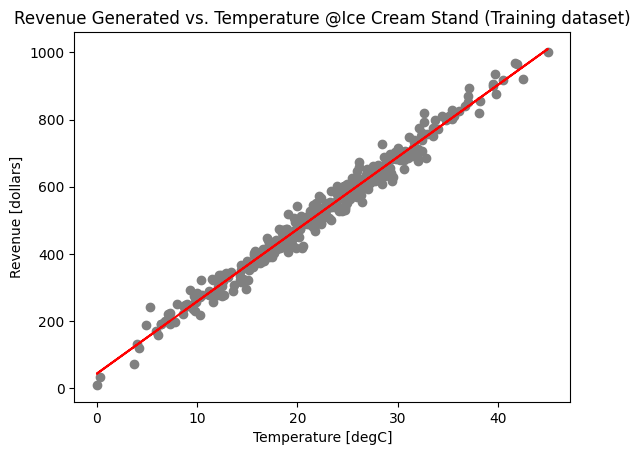

In [73]:
plt.scatter(X_train, y_train, color = 'gray')
plt.plot(X_train, model.predict(X_train), color = 'red')
plt.ylabel('Revenue [dollars]')
plt.xlabel('Temperature [degC]')
plt.title('Revenue Generated vs. Temperature @Ice Cream Stand (Training dataset)')

Text(0.5, 1.0, 'Revenue Generated vs. Hours @Ice Cream Stand (Test dataset)')

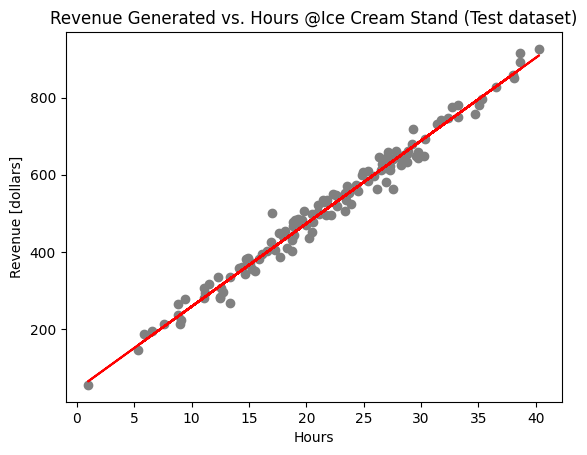

In [74]:
# VISUALIZE TEST SET RESULTS
plt.scatter(X_test, y_test, color = 'gray')
plt.plot(X_test, model.predict(X_test), color = 'red')
plt.ylabel('Revenue [dollars]')
plt.xlabel('Hours')
plt.title('Revenue Generated vs. Hours @Ice Cream Stand (Test dataset)')

In [75]:
y_predict = model.predict([[12]])
y_predict

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([301.53677294])

# EXCELLENT JOB! NOW YOU BECAME EXPERT IN SIMPLE LINEAR REGRESSION